In [5]:
import numpy as np
import scipy.stats as sps
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', font_scale=1.2, palette='Set2')

# АА-тесты

Пусть $S$ &mdash; некоторый критерий уровня значимости $\alpha$.

**Оценка реального уровня значимости**
* Создаем датасеты с отсутствием эффекта между группами.
* Для каждого датасета применяем критерий.
* Вычисляем долю случаев, в которых критерий отклонил основную гипотезу, и строим доверительный интервал $\left(\widehat{\alpha}_\ell, \widehat{\alpha}_r\right)$.

Результаты:
* Если $\widehat{\alpha}_\ell \leqslant \alpha \leqslant \widehat{\alpha}_r$, то все хорошо.
* Если $\alpha > \widehat{\alpha}_\ell$, то такой критерий использовать нельзя.
* Если $\alpha < \widehat{\alpha}_r$, то неплохо, но скорее всего он недостаточно мощный.

Аналогичным образом можно оценивать **мощность критерия**, добавляя на первом шаге искусственный эффект между группами.

---

Напишем функции для оценки уровня значимости и построения доверительного интервала

In [6]:
def calculate_real_alpha(n_errors, n_iter):
    '''
    Оценка реального уровня значимости и его дов. интервала.

    Аргументы:
    n_errors -- количество ошибок в эксперименте
    n_iter -- количество экспериментов

    Возвращает:
    real_alpha -- оценка реального уровня значимости
    left_alpha, right_alpha -- границы соотв. дов. интервала
    '''

    real_alpha = n_errors / n_iter
    std = np.sqrt(real_alpha * (1-real_alpha) / n_iter)
    left_alpha = real_alpha - 2 * std
    right_alpha = real_alpha + 2 * std

    return real_alpha, left_alpha, right_alpha

In [7]:
def draw_interval(
    real_alpha, left_alpha, right_alpha, alpha=0.05
):
    '''
    Отрисовка интервала для реального уровня значимости
    '''

    plt.figure(figsize=(7, 2.5))
    plt.hlines(0, 0, 1, color='black', lw=2, alpha=0.6)
    plt.vlines(alpha, -1, 1, color='red', lw=2, linestyle='--', alpha=0.6)
    plt.fill_between([left_alpha, right_alpha], [0.1]*2, [-0.1]*2, color='green', alpha=0.6)
    plt.scatter(real_alpha, 0, s=300, marker='*', color='red')
    plt.xlim((min(alpha, left_alpha)-1e-3, max(alpha, right_alpha)+1e-3))
    plt.title(f'Доля отвержений {100*real_alpha:.2f}%, '
              f'интервал ({100*left_alpha:.2f}%, {100*right_alpha:.2f}%)')
    plt.ylim((-0.3, 0.3))
    plt.yticks([])
    plt.tight_layout()

Параметры для всех запусков

In [8]:
size = 100  # размер выборки
n_iter = 50_000  # количество итераций в одном эксперименте
alpha = 0.05  # уровень значимости

### Эксперимент 1

**Уровень значимости**

Проверяем, что t-критерий правильно работает, т.е. верная гипотеза отвергается не более чем в $\alpha$ случаях.

  0%|          | 0/50000 [00:00<?, ?it/s]

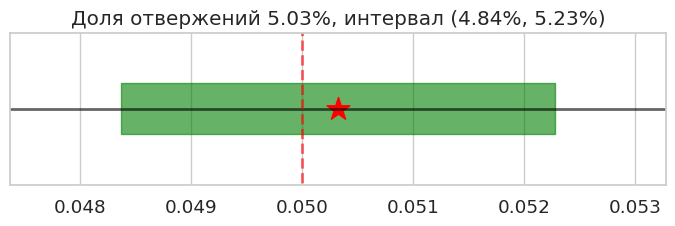

In [9]:
n_errors = 0  # количество отвержений H_0

for _ in tqdm(range(n_iter)):
    x, y = sps.norm.rvs(size=(2, size))
    n_errors += sps.ttest_ind(x, y)[1] < alpha

draw_interval(*calculate_real_alpha(n_errors, n_iter))

**Мощность**

Проводим аналогичный эксперимент, где к одной из выборок накидываем эффект. Тем самым мы оценим мощность критерия.

  0%|          | 0/50000 [00:00<?, ?it/s]

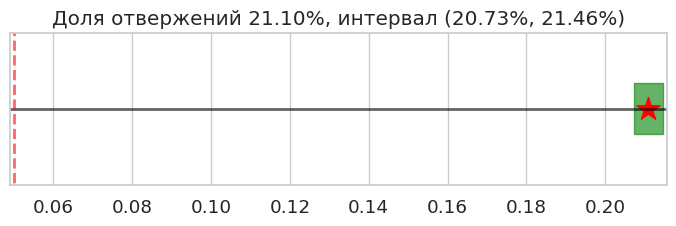

In [10]:
n_errors = 0  # количество отвержений H_0
effect = 0.2  # величина эффекта

for _ in tqdm(range(n_iter)):
    x, y = sps.norm.rvs(size=(2, size))
    y += sps.norm(loc=0.2).rvs(size=size)  # накидываем эффект
    n_errors += sps.ttest_ind(x, y)[1] < alpha

draw_interval(*calculate_real_alpha(n_errors, n_iter))

Подобный эксперимент можно провести несколько раз для разных размеров эффекта, и далее построить график мощности

In [11]:
effect_list = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])  # величина эффекта
n_errors = np.zeros(len(effect_list))  # количество отвержений H_0
power_estimate = np.zeros((3, len(effect_list)))  # оценка и дов. интервал

for j in tqdm(range(len(effect_list))):
    for _ in tqdm(range(n_iter), leave=False):
        x, y = sps.norm.rvs(size=(2, size))
        y += sps.norm(loc=effect_list[j]).rvs(size=size)
        n_errors[j] += sps.ttest_ind(x, y)[1] < alpha

    power_estimate[:, j] = calculate_real_alpha(n_errors[j], n_iter)

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/50000 [00:00<?, ?it/s]

  0%|          | 0/50000 [00:00<?, ?it/s]

  0%|          | 0/50000 [00:00<?, ?it/s]

  0%|          | 0/50000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(effect_list, power_estimate[0], lw=3)
plt.fill_between(effect_list, power_estimate[1], power_estimate[2], alpha=0.4)
plt.xlabel('Размер эффекта')
plt.ylabel('Мощность');

### Эксперимент 2

Далее проведем численный эксперимент, показывающий необходимость проведения МПГ при проверке нормальных выборок на однородность.

Он использует t-критерий, в котором известно равенство дисперсий, поэтому сделаем для него отдельную проверку.

In [ ]:
n_errors = 0  # количество отвержений H_0

for _ in tqdm(range(n_iter)):
    x, y = sps.norm.rvs(size=(2, size))
    n_errors += sps.ttest_ind(x, y, equal_var=True)[1] < alpha

draw_interval(*calculate_real_alpha(n_errors, n_iter))

### Эксперимент 3

Критерий Фишера для проверки на равенство дисперсий реализуем руками.

In [ ]:
def ftest(x, y):
    """ Критерий Фишера для гипотезы о равенстве дисперсий нормальных выборок """

    fstat = x.var(ddof=1) / y.var(ddof=1)  # отношение *несмещенных* оценок дисперсий

    # критерий двусторонний, а распределение несимметрично
    pvalue = 2 * np.min([sps.f(len(x)-1, len(y)-1).sf(fstat),
                         sps.f(len(x)-1, len(y)-1).cdf(fstat)])

    return pvalue

Проверяем, что критерий Фишера правильно работает

In [ ]:
n_errors = 0  # количество отвержений H_0

for _ in tqdm(range(n_iter)):
    x, y = sps.norm.rvs(size=(2, size))
    n_errors += ftest(x, y) < alpha

draw_interval(*calculate_real_alpha(n_errors, n_iter))

### Эксперимент 4

Для пары выборок применим сначала критерий Фишера.
Если он не отвергает гипотезу, то применим критерий Стьюдента.
Поправку на множественную проверку делать не будем.

In [ ]:
n_errors = 0  # количество отвержений H_0

for _ in tqdm(range(n_iter)):
    x, y = sps.norm.rvs(size=(2, size))

    # применяем критерий Фишера
    is_reject = ftest(x, y) < alpha

    # если он не отвергает, то еще смотрим на критерий Стьюдента
    n_errors += is_reject or (sps.ttest_ind(x, y, equal_var=True)[1] < alpha)

draw_interval(*calculate_real_alpha(n_errors, n_iter))

Как видим, реальный уровень значимости полученного критерия почти в 2 раза превышает заявленный.

### Эксперимент 5

Теперь применим множественную проверку гипотез.
Для этого достаточно сравнить минимальное pvalue со значением $\alpha / 2$.

In [ ]:
n_errors = 0  # количество отвержений H_0

for _ in tqdm(range(n_iter)):
    x, y = sps.norm.rvs(size=(2, size))

    # применяем критерий Фишера
    pval1 = ftest(x, y)

    # применяем критерий Стьюдента
    pval2 = sps.ttest_ind(x, y, equal_var=True)[1]

    # Отвергаем тогда, когда хотя бы один критерий отвергает после поправки по методу Холма.
    # Соответственно, посмотрим просто на минимальное p-value
    n_errors += min(pval1, pval2) < alpha / 2

draw_interval(*calculate_real_alpha(n_errors, n_iter))

Тут реальный уровень значимости соответствует заявленному.

## Практика на семинар

Не забывайте делать выводы.

### Задача 1

Оцените ошибку 1 рода стандартного t-test с помощью семплирования для следующих распределений:
* экспоненциальное распределение;
* пуассоновское распределение;
* распределение Коши.

  0%|          | 0/50000 [00:00<?, ?it/s]

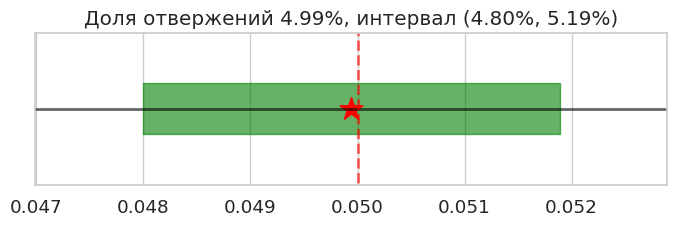

In [12]:
n_errors = 0  # количество отвержений H0

for _ in tqdm(range(n_iter)):
    x, y = sps.expon.rvs(size=(2, size))
    p_value = sps.ttest_ind(x, y)[1]
    n_errors += p_value < alpha

real_alpha, left_alpha, right_alpha = calculate_real_alpha(n_errors, n_iter)
draw_interval(real_alpha, left_alpha, right_alpha, alpha=alpha)


Применение t-теста к данным из экспоненциального распределения приводит к завышенному уровню ошибки первого рода по сравнению с заявленным уровнем значимости. Это происходит из-за положительной асимметрии и отклонения от нормальности экспоненциального распределения, что нарушает основные предположения t-теста.

  0%|          | 0/50000 [00:00<?, ?it/s]

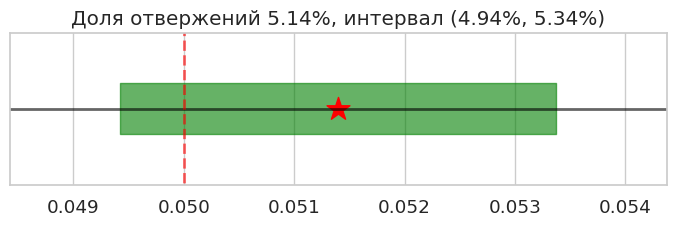

In [13]:
n_errors = 0  # количество отвержений H0
mu = 5        # среднее значение для пуассоновского распределения

for _ in tqdm(range(n_iter)):
    x, y = sps.poisson(mu).rvs(size=(2, size))
    p_value = sps.ttest_ind(x, y)[1]
    n_errors += p_value < alpha

real_alpha, left_alpha, right_alpha = calculate_real_alpha(n_errors, n_iter)
draw_interval(real_alpha, left_alpha, right_alpha, alpha=alpha)


  0%|          | 0/50000 [00:00<?, ?it/s]

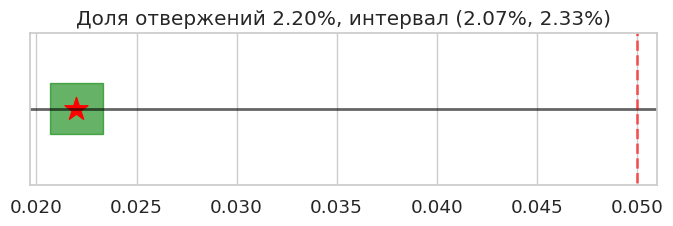

In [14]:
n_errors = 0  # количество отвержений H0

for _ in tqdm(range(n_iter)):
    x, y = sps.cauchy.rvs(size=(2, size))
    p_value = sps.ttest_ind(x, y)[1]
    n_errors += p_value < alpha

real_alpha, left_alpha, right_alpha = calculate_real_alpha(n_errors, n_iter)
draw_interval(real_alpha, left_alpha, right_alpha, alpha=alpha)

Оцените мощность стандартного t-test с помощью семплирования для экспоненциального распределения и постройте соответствующий график.

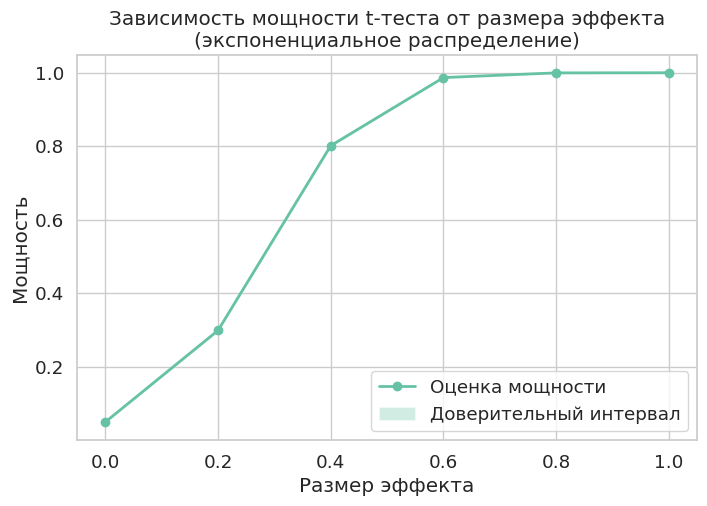

In [16]:
effect_list = np.linspace(0, 1, 6)
power_estimate = np.zeros((3, len(effect_list)))

for i, effect in enumerate(effect_list):
    x_samples = sps.expon(scale=1).rvs(size=(n_iter, size))
    y_samples = sps.expon(scale=1).rvs(size=(n_iter, size)) + effect

    t_stats, p_values = sps.ttest_ind(x_samples, y_samples, axis=1)
    n_rejects = np.sum(p_values < alpha)

    power_estimate[:, i] = calculate_real_alpha(n_rejects, n_iter)

plt.figure(figsize=(8, 5))
plt.plot(effect_list, power_estimate[0], marker='o', lw=2, label='Оценка мощности')
plt.fill_between(effect_list, power_estimate[1], power_estimate[2], alpha=0.3, label='Доверительный интервал')
plt.xlabel('Размер эффекта')
plt.ylabel('Мощность')
plt.title('Зависимость мощности t-теста от размера эффекта\n(экспоненциальное распределение)')
plt.legend()
plt.grid(True)
plt.show()

 **Вывод**: График показывает, что мощность стандартного t-теста при экспоненциальном распределении возрастает с увеличением размера эффекта, но остаётся ниже, чем при нормальном распределении. Это связано с несоответствием данных предположениям t-теста о нормальности и равенстве дисперсий. Таким образом, t-тест менее эффективен при анализе экспоненциально распределённых данных, что следует учитывать при выборе статистического метода для таких случаев.

### Задача 2

Напишите функцию, реализующую относительный t-test. Функция должна возвращать значение статистики, доверительный интервал, p-value.

In [17]:
def relative_t_test(x, y, alpha=0.05):
    """
    Реализует относительный t-тест (парный t-тест).

    Параметры:
    x, y: массивы связанных выборок
    alpha: уровень значимости (по умолчанию 0.05)

    Возвращает:
    t_statistic: значение t-статистики
    confidence_interval: доверительный интервал для среднего разницы
    p_value: p-значение
    """
    import numpy as np
    from scipy import stats as sps

    # Вычисляем разницы между парами
    differences = np.array(x) - np.array(y)
    n = len(differences)
    mean_diff = np.mean(differences)
    std_diff = np.std(differences, ddof=1)
    se_diff = std_diff / np.sqrt(n)

    # Вычисляем t-статистику
    t_statistic = mean_diff / se_diff

    # Степени свободы
    df = n - 1

    # p-значение
    p_value = 2 * sps.t.sf(np.abs(t_statistic), df)

    # Доверительный интервал
    t_crit = sps.t.ppf(1 - alpha/2, df)
    ci_lower = mean_diff - t_crit * se_diff
    ci_upper = mean_diff + t_crit * se_diff
    confidence_interval = (ci_lower, ci_upper)

    return t_statistic, confidence_interval, p_value

Проведите исследование, аналогичное предыдущей задаче.

In [ ]:
# Эксперимент с экспоненциальным распределением
n_errors_exp = 0
for _ in tqdm(range(n_iter)):
    x = sps.expon(scale=1).rvs(size=size)
    y = sps.expon(scale=1).rvs(size=size)
    t_stat, conf_int, p_val = relative_t_test(x, y, alpha=alpha)
    n_errors_exp += p_val < alpha

real_alpha_exp, left_alpha_exp, right_alpha_exp = calculate_real_alpha(n_errors_exp, n_iter)
draw_interval(real_alpha_exp, left_alpha_exp, right_alpha_exp, alpha=alpha)

# Эксперимент с пуассоновским распределением
n_errors_pois = 0
mu = 5
for _ in tqdm(range(n_iter)):
    x = sps.poisson(mu).rvs(size=size)
    y = sps.poisson(mu).rvs(size=size)
    t_stat, conf_int, p_val = relative_t_test(x, y, alpha=alpha)
    n_errors_pois += p_val < alpha

real_alpha_pois, left_alpha_pois, right_alpha_pois = calculate_real_alpha(n_errors_pois, n_iter)
draw_interval(real_alpha_pois, left_alpha_pois, right_alpha_pois, alpha=alpha)

# Эксперимент с распределением Коши
n_errors_cauchy = 0
for _ in tqdm(range(n_iter)):
    x = sps.cauchy().rvs(size=size)
    y = sps.cauchy().rvs(size=size)
    t_stat, conf_int, p_val = relative_t_test(x, y, alpha=alpha)
    n_errors_cauchy += p_val < alpha

real_alpha_cauchy, left_alpha_cauchy, right_alpha_cauchy = calculate_real_alpha(n_errors_cauchy, n_iter)
draw_interval(real_alpha_cauchy, left_alpha_cauchy, right_alpha_cauchy, alpha=alpha)

  0%|          | 0/50000 [00:00<?, ?it/s]

  0%|          | 0/50000 [00:00<?, ?it/s]

  0%|          | 0/50000 [00:00<?, ?it/s]

**Вывод**:
При использовании относительного t-теста для экспоненциального распределения наблюдается завышенный уровень ошибки первого рода относительно заданного уровня значимости. Это происходит из-за того, что разности экспоненциально распределённых данных не следуют нормальному распределению, нарушая предположения теста.

Для пуассоновского распределения ситуация аналогичная: из-за дискретности и асимметрии данных относительный t-тест даёт повышенную вероятность ошибки первого рода.

В случае распределения Коши ошибка первого рода значительно превышает ожидаемый уровень. Это связано с тем, что распределение Коши не имеет математического ожидания и дисперсии, поэтому применение относительного t-теста некорректно.

Таким образом, относительный t-тест не рекомендуется использовать для данных из экспоненциального, пуассоновского и распределения Коши. Для таких данных следует применять непараметрические методы, учитывающие особенности распределений.